# YAMNet Transfer Learning for Audio Classification

In this notebook, we build an effective audio classifier by applying transfer learning to the pre-trained YAMNet model from TensorFlow Hub. 


In [2]:
# Optional: install packages that are commonly needed in Colab.
# If a package is already available, this cell will simply confirm it.
!pip -q install tensorflow-hub seaborn librosa

from google.colab import drive
drive.mount('/content/drive')

import os
import random

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Reproducibility helpers.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------------------------------------------------------
# Google Drive dataset paths
# Update these placeholders if your dataset lives in a different location.
# -----------------------------------------------------------------------------
DATA_ROOT = '/content/drive/MyDrive/ResoNET'

# ESC-50 metadata and audio directory.
ESC50_METADATA_CSV = os.path.join(DATA_ROOT, 'Cleaned_ESC50.csv')
ESC50_AUDIO_DIR = os.path.join(DATA_ROOT, 'ESC50_16000')

# FSD50K metadata and audio directories.
FSD50K_DEV_METADATA_CSV = os.path.join(DATA_ROOT, 'FSD50K_dev_cleaned.csv')
FSD50K_DEV_AUDIO_DIR = os.path.join(DATA_ROOT, 'FSD50K.dev_audio_16k')
FSD50K_EVAL_METADATA_CSV = os.path.join(DATA_ROOT, 'FSDK50_eval_cleaned.csv')
FSD50K_EVAL_AUDIO_DIR = os.path.join(DATA_ROOT, 'FSD50K.eval_audio_16k')

# Column names used by the metadata CSV files.
FILENAME_COLUMN = 'fname'
LABEL_COLUMN = 'labels'
AUDIO_EXTENSION = '.wav'

# Audio and training configuration.
TARGET_SAMPLE_RATE = 16000
TEST_SIZE = 0.15
VAL_SIZE = 0.15
BATCH_SIZE = 32
EPOCHS = 30

print('Drive root:', DRIVE_ROOT)
print('ESC-50 CSV:', ESC50_METADATA_CSV)
print('ESC-50 audio dir:', ESC50_AUDIO_DIR)
print('FSD50K dev CSV:', FSD50K_DEV_METADATA_CSV)
print('FSD50K dev audio dir:', FSD50K_DEV_AUDIO_DIR)
print('FSD50K eval CSV:', FSD50K_EVAL_METADATA_CSV)
print('FSD50K eval audio dir:', FSD50K_EVAL_AUDIO_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/MyDrive/ResoNET
ESC-50 CSV: /content/drive/MyDrive/ResoNET/Cleaned_ESC50.csv
ESC-50 audio dir: /content/drive/MyDrive/ResoNET/ESC50_16000
FSD50K dev CSV: /content/drive/MyDrive/ResoNET/FSD50K_dev_cleaned.csv
FSD50K dev audio dir: /content/drive/MyDrive/ResoNET/FSD50K.dev_audio_16k
FSD50K eval CSV: /content/drive/MyDrive/ResoNET/FSDK50_eval_cleaned.csv
FSD50K eval audio dir: /content/drive/MyDrive/ResoNET/FSD50K.eval_audio_16k


## 1. Data Loading and Preprocessing

To work correctly, YAMNet requires 16 kHz mono waveforms. We implement a data loader that automatically resamples each file to 16,000 Hz, converts it to a single channel, and normalizes the waveform values to stay perfectly within the [-1.0, 1.0] range.

In [3]:
def build_audio_path(file_name: str, audio_dir: str) -> str:
    """Build the full audio path for a file name stored in the CSV."""
    file_name = str(file_name)
    if not file_name.lower().endswith(AUDIO_EXTENSION):
        file_name = file_name + AUDIO_EXTENSION
    return os.path.join(audio_dir, file_name)


def load_audio_16k_mono(audio_path: str, target_sr: int = TARGET_SAMPLE_RATE) -> np.ndarray:
    """
    Load an audio file, resample it to 16 kHz, convert to mono, and normalize
    the waveform to keep values inside [-1.0, 1.0].
    """
    waveform, _ = librosa.load(audio_path, sr=target_sr, mono=True)
    waveform = waveform.astype(np.float32)

    # Normalize by peak amplitude so the waveform stays inside [-1, 1].
    peak = np.max(np.abs(waveform))
    if peak > 0:
        waveform = waveform / peak

    waveform = np.clip(waveform, -1.0, 1.0)
    return waveform


def load_metadata_and_paths(metadata_csv: str, audio_dir: str, dataset_name: str) -> pd.DataFrame:
    """Load a metadata CSV and add dataset and audio_path columns."""
    df = pd.read_csv(metadata_csv)
    if FILENAME_COLUMN not in df.columns:
        raise ValueError(f'Missing file-name column: {FILENAME_COLUMN}')
    if LABEL_COLUMN not in df.columns:
        raise ValueError(f'Missing label column: {LABEL_COLUMN}')

    df = df.copy()
    df['dataset'] = dataset_name
    df['audio_path'] = df[FILENAME_COLUMN].apply(lambda value: build_audio_path(value, audio_dir))
    df = df[df['audio_path'].apply(os.path.exists)].reset_index(drop=True)
    return df


esc50_df = load_metadata_and_paths(ESC50_METADATA_CSV, ESC50_AUDIO_DIR, 'ESC-50')
fsd50k_dev_df = load_metadata_and_paths(FSD50K_DEV_METADATA_CSV, FSD50K_DEV_AUDIO_DIR, 'FSD50K-dev')
fsd50k_eval_df = load_metadata_and_paths(FSD50K_EVAL_METADATA_CSV, FSD50K_EVAL_AUDIO_DIR, 'FSD50K-eval')

df = pd.concat([esc50_df, fsd50k_dev_df, fsd50k_eval_df], ignore_index=True)
print('Loaded rows from ESC-50:', len(esc50_df))
print('Loaded rows from FSD50K dev:', len(fsd50k_dev_df))
print('Loaded rows from FSD50K eval:', len(fsd50k_eval_df))
print('Combined rows:', len(df))
display(df.head())
print('Number of classes:', df[LABEL_COLUMN].nunique())
print('Rows per dataset:')
display(df['dataset'].value_counts())
print('Class distribution:')
display(df[LABEL_COLUMN].value_counts())

# Encode string labels into integers first, then convert to categorical arrays later.
label_encoder = LabelEncoder()
df['label_id'] = label_encoder.fit_transform(df[LABEL_COLUMN].astype(str).str.strip())
class_names = label_encoder.classes_
num_classes = len(class_names)
print('Classes:', list(class_names))

# Split the combined dataset into train/validation/test sets using a stratified split whenever possible.
label_counts = df['label_id'].value_counts()
can_stratify = label_counts.min() >= 2
stratify_series = df['label_id'] if can_stratify else None

train_df, temp_df = train_test_split(
    df,
    test_size=TEST_SIZE + VAL_SIZE,
    random_state=SEED,
    stratify=stratify_series,
)

relative_val_size = VAL_SIZE / (TEST_SIZE + VAL_SIZE)
temp_stratify = temp_df['label_id'] if can_stratify and temp_df['label_id'].value_counts().min() >= 2 else None
val_df, test_df = train_test_split(
    temp_df,
    test_size=1.0 - relative_val_size,
    random_state=SEED,
    stratify=temp_stratify,
)

train_paths = train_df['audio_path'].tolist()
val_paths = val_df['audio_path'].tolist()
test_paths = test_df['audio_path'].tolist()

y_train_int = train_df['label_id'].to_numpy()
y_val_int = val_df['label_id'].to_numpy()
y_test_int = test_df['label_id'].to_numpy()

y_train = tf.keras.utils.to_categorical(y_train_int, num_classes=num_classes)
y_val = tf.keras.utils.to_categorical(y_val_int, num_classes=num_classes)
y_test = tf.keras.utils.to_categorical(y_test_int, num_classes=num_classes)

print('Train / Val / Test sizes:', len(train_paths), len(val_paths), len(test_paths))


Loaded rows from ESC-50: 200
Loaded rows from FSD50K dev: 2253
Loaded rows from FSD50K eval: 1004
Combined rows: 3457


,fname,fold,target,labels,esc10,src_file,take,dataset,audio_path,mids,split
0,1-101336-A-30,1.0,30.0,door_wood_knock,False,101336.0,A,ESC-50,/content/drive/MyDrive/ResoNET/ESC50_16000/1-1...,NaN,NaN
1,1-103995-A-30,1.0,30.0,door_wood_knock,False,103995.0,A,ESC-50,/content/drive/MyDrive/ResoNET/ESC50_16000/1-1...,NaN,NaN
2,1-103999-A-30,1.0,30.0,door_wood_knock,False,103999.0,A,ESC-50,/content/drive/MyDrive/ResoNET/ESC50_16000/1-1...,NaN,NaN
3,1-13571-A-46,1.0,46.0,church_bells,False,13571.0,A,ESC-50,/content/drive/MyDrive/ResoNET/ESC50_16000/1-1...,NaN,NaN
4,1-13572-A-46,1.0,46.0,church_bells,False,13572.0,A,ESC-50,/content/drive/MyDrive/ResoNET/ESC50_16000/1-1...,NaN,NaN


Number of classes: 7
Rows per dataset:


,count
dataset,
FSD50K-dev,2253
FSD50K-eval,1004
ESC-50,200


Class distribution:


,count
labels,
Doorbell,1679
Alarm,1578
door_wood_knock,40
clock_alarm,40
church_bells,40
siren,40
glass_breaking,40


Classes: ['Alarm', 'Doorbell', 'church_bells', 'clock_alarm', 'door_wood_knock', 'glass_breaking', 'siren']
Train / Val / Test sizes: 2419 519 519


## 2. YAMNet Feature Extraction

When we pass a 16 kHz mono waveform to the YAMNet model from TensorFlow Hub, it produces three distinct outputs:
1. Frame-level class scores
2. Deep embeddings
3. Spectrogram features

For our purposes, we will completely bypass the class scores and directly extract the rich, learned embeddings. Since individual audio clips can yield multiple embedding frames over time, we smoothly average them to create a single, powerful 1024-dimensional vector that represents the entire clip.

In [4]:
YAMNET_URL = 'https://tfhub.dev/google/yamnet/1'
yamnet_model = hub.load(YAMNET_URL)
print('YAMNet loaded successfully.')


def extract_yamnet_embedding(waveform: np.ndarray) -> np.ndarray:
    """
    Pass a 16 kHz mono waveform through YAMNet and return the mean embedding.
    The returned vector is 1024-dimensional.
    """
    waveform = tf.convert_to_tensor(waveform, dtype=tf.float32)
    scores, embeddings, spectrogram = yamnet_model(waveform)

    # Average embeddings across time so every clip becomes one fixed-size vector.
    embedding = tf.reduce_mean(embeddings, axis=0)
    return embedding.numpy().astype(np.float32)


def build_embedding_matrix(audio_paths: list[str], labels: np.ndarray | None = None):
    """Load audio files, extract YAMNet embeddings, and return NumPy arrays."""
    embeddings = []
    valid_labels = [] if labels is not None else None

    for index, audio_path in enumerate(audio_paths):
        try:
            waveform = load_audio_16k_mono(audio_path)
            embedding = extract_yamnet_embedding(waveform)
            embeddings.append(embedding)
            if labels is not None:
                valid_labels.append(labels[index])
        except Exception as exc:
            print(f'Skipping {audio_path}: {exc}')

    embeddings = np.asarray(embeddings, dtype=np.float32)
    if labels is None:
        return embeddings

    valid_labels = np.asarray(valid_labels)
    return embeddings, valid_labels


X_train, y_train = build_embedding_matrix(train_paths, y_train)
X_val, y_val = build_embedding_matrix(val_paths, y_val)
X_test, y_test = build_embedding_matrix(test_paths, y_test)

print('Embedding shapes:')
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val  :', X_val.shape, 'y_val  :', y_val.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)

YAMNet loaded successfully.
Embedding shapes:
X_train: (2419, 1024) y_train: (2419, 7)
X_val  : (519, 1024) y_val  : (519, 7)
X_test : (519, 1024) y_test : (519, 7)


## 3. Custom Classification Head

We intentionally design our new classifier to be lightweight and straightforward. It effortlessly accepts the fixed YAMNet embedding vector as its input. From there, we channel the data through a few dense layers equipped with ReLU activations and dropout for regularization. Finally, a robust softmax layer yields perfectly sized predictions corresponding to our list of classes.

In [5]:
embedding_dim = X_train.shape[1]

classifier = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(embedding_dim,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax'),
])

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,199 (1.13 MB)

 Trainable params: 296,199 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training and Learning Curves

Now we train our classifier. We use EarlyStopping and ReduceLROnPlateau callbacks. This ensures our model stops training precisely before it begins to overfit, and it dynamically lowers the learning rate the moment our validation loss stops improving.

Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.7301 - loss: 0.8672 - val_accuracy: 0.7360 - val_loss: 0.5819 - learning_rate: 0.0010
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7826 - loss: 0.6220 - val_accuracy: 0.8247 - val_loss: 0.4927 - learning_rate: 0.0010
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8041 - loss: 0.5546 - val_accuracy: 0.8285 - val_loss: 0.4767 - learning_rate: 0.0010
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8107 - loss: 0.5208 - val_accuracy: 0.8324 - val_loss: 0.4486 - learning_rate: 0.0010
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8131 - loss: 0.5134 - val_accuracy: 0.8227 - val_loss: 0.4565 - learning_rate: 0.0010
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8185 - loss: 0.4950 - val_accuracy: 0.8304 - val_loss: 0.4444 - learning_rate: 0.0010
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8404 - loss: 0.4374 - val_accuracy:

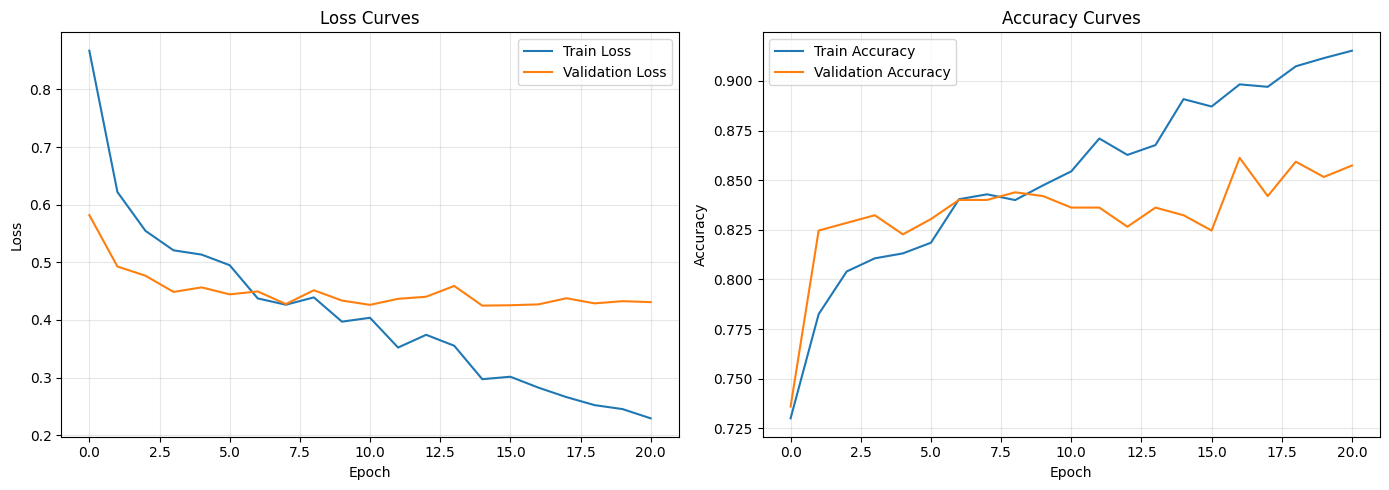

In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = classifier.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

# Plot loss and accuracy curves.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Test Evaluation

In the final step, we evaluate our fully trained model on the unseen test set. We generate a detailed classification report to measure our performance metrics, and we visualize the exact hits and misses by plotting a confusion matrix.

Test loss: 0.3860
Test accuracy: 0.8613

Classification Report:
                 precision    recall  f1-score   support

          Alarm       0.88      0.89      0.88       237
       Doorbell       0.86      0.91      0.89       252
   church_bells       0.60      0.50      0.55         6
    clock_alarm       0.00      0.00      0.00         6
door_wood_knock       0.00      0.00      0.00         6
 glass_breaking       1.00      0.17      0.29         6
          siren       0.43      0.50      0.46         6

       accuracy                           0.86       519
      macro avg       0.54      0.42      0.44       519
   weighted avg       0.84      0.86      0.85       519



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


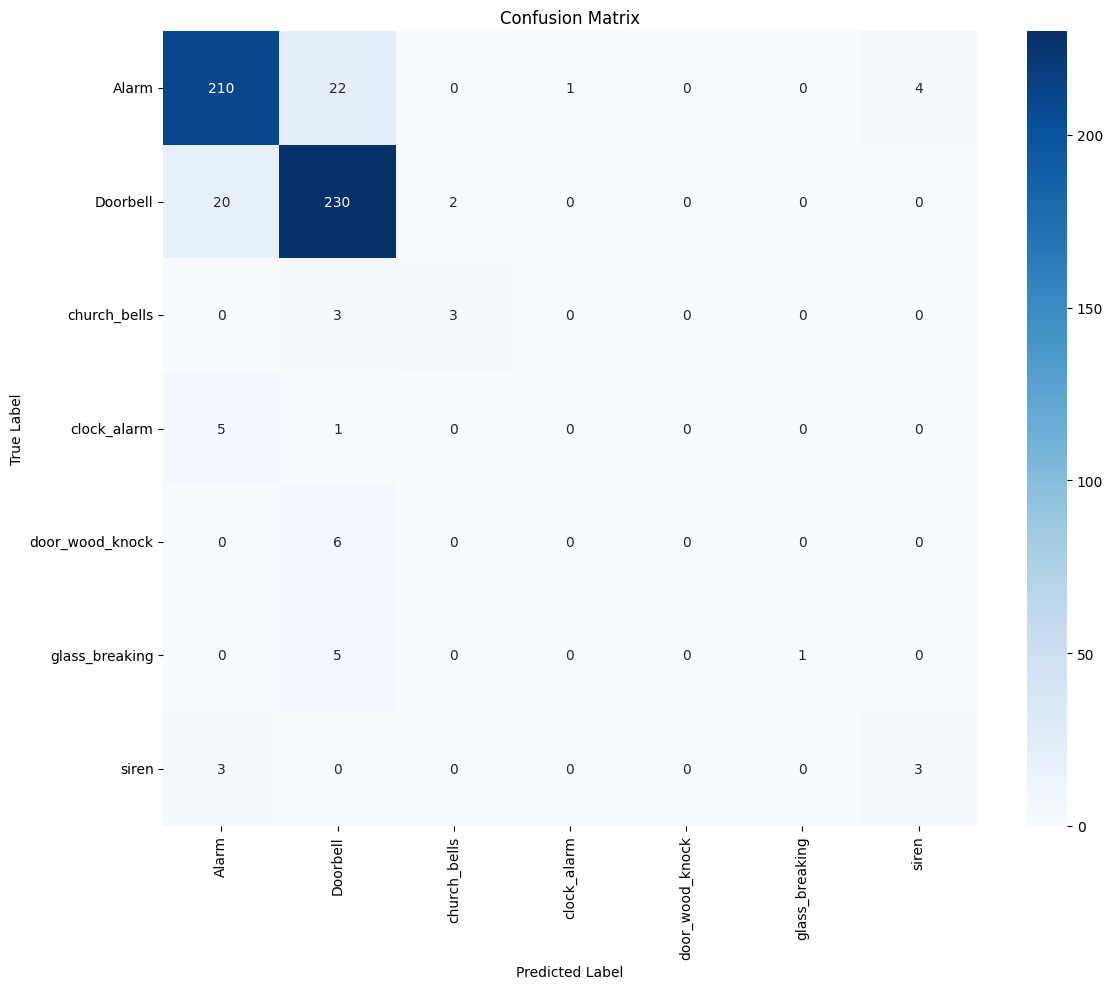

In [7]:
test_loss, test_accuracy = classifier.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

y_true = np.argmax(y_test, axis=1)
y_prob = classifier.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()